### Wczytywanie danych

In [ ]:
import pandas as pd

with open('normal_small.xlsx', 'rb') as file:
    data = pd.read_excel(file)

df = pd.DataFrame(data)
df.columns = ['Time', 'Voltage [mV]']
df.index = df.index + 1
df.head()

,Time,Voltage [mV]
1,0.003995,-0.449
2,0.007989,-0.435
3,0.011984,-0.392
4,0.015979,-0.394
5,0.019973,-0.376


In [11]:
# Wyliczenie fs
delta_t = df["Time"].diff().mean()
fs = 1 / delta_t
print(f"Częstotliwość próbkowania wynosi: {round(fs, 0)} [Hz]")

Częstotliwość próbkowania wynosi: 250.0 [Hz]


### Analiza częstotliwości składowych (FFT)

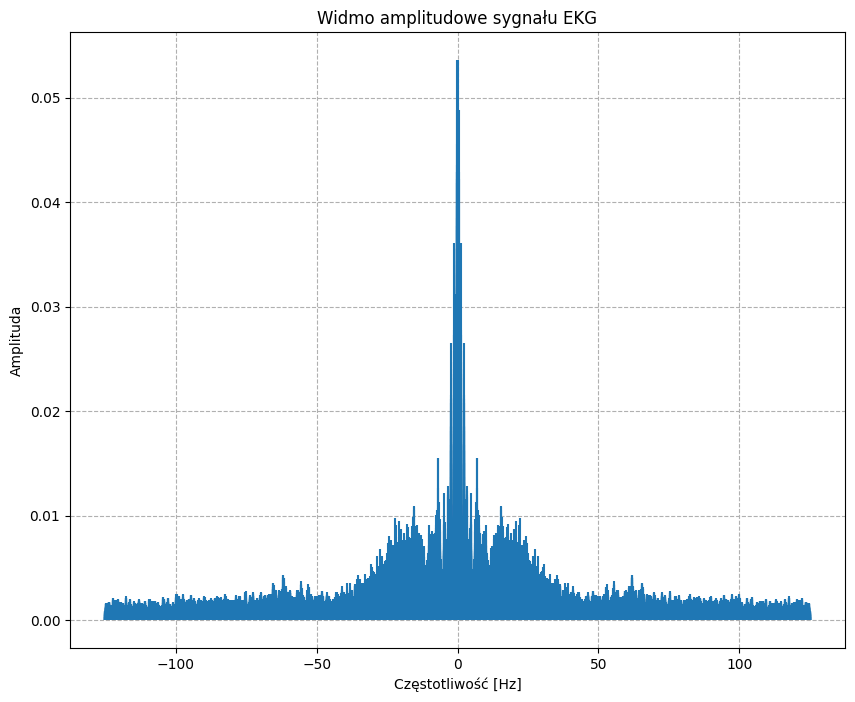

In [18]:
import matplotlib.pyplot as plt
import numpy as np

base_signal = df["Voltage [mV]"].values

def fft_plot(signal, fs):
    n = len(signal)
    delta_t = 1.0 / fs
    fft_values = np.fft.fft(signal)
    freq = np.fft.fftfreq(n, d=delta_t)
    amplitude = np.abs(fft_values) * (2.0 / n)

    plt.figure(figsize=(10, 8))
    plt.stem(freq, amplitude, linefmt='-', markerfmt=' ', basefmt=' ')
    plt.title('Widmo amplitudowe sygnału EKG')
    plt.xlabel('Częstotliwość [Hz]')
    plt.ylabel('Amplituda')
    plt.grid(linestyle='--')

fft_plot(base_signal, fs=250)

### Preprocesing

##### Usunięcie dryftu

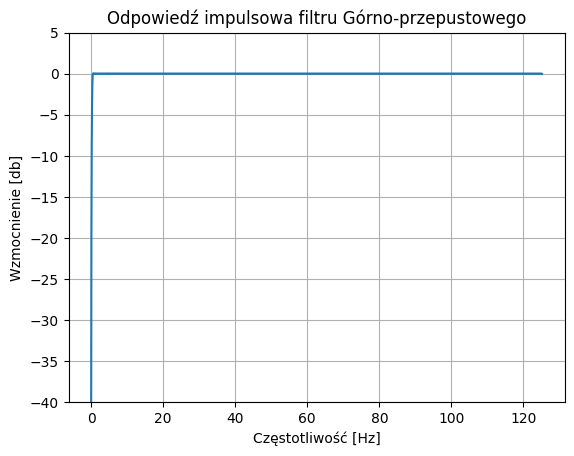

In [24]:
from scipy import signal

def odpowiedz_impulsowa(w, h, title):
    fig = plt.figure()
    ax = fig.add_subplot(111)
    ax.plot(w, 20*np.log10(np.abs(h)))
    ax.set_ylim(-40, 5)
    ax.grid(True)
    ax.set_xlabel('Częstotliwość [Hz]')
    ax.set_ylabel('Wzmocnienie [db]')
    ax.set_title(title)
    plt.show()

cutoff = 0.5
trans_width = 0.5
numtaps = 1025
taps = signal.remez(
    numtaps,
    [0.0, cutoff - trans_width, cutoff, 0.5 * fs], 
    [0, 1],                       
    fs=fs                         
)

w_hp, h_hp = signal.freqz(taps, [1.0], worN=4096, fs=fs)

odpowiedz_impulsowa(w_hp, h_hp, 'Odpowiedź impulsowa filtru Górno-przepustowego')
hp_filtred_signal = signal.lfilter(taps, [1.0], base_signal)

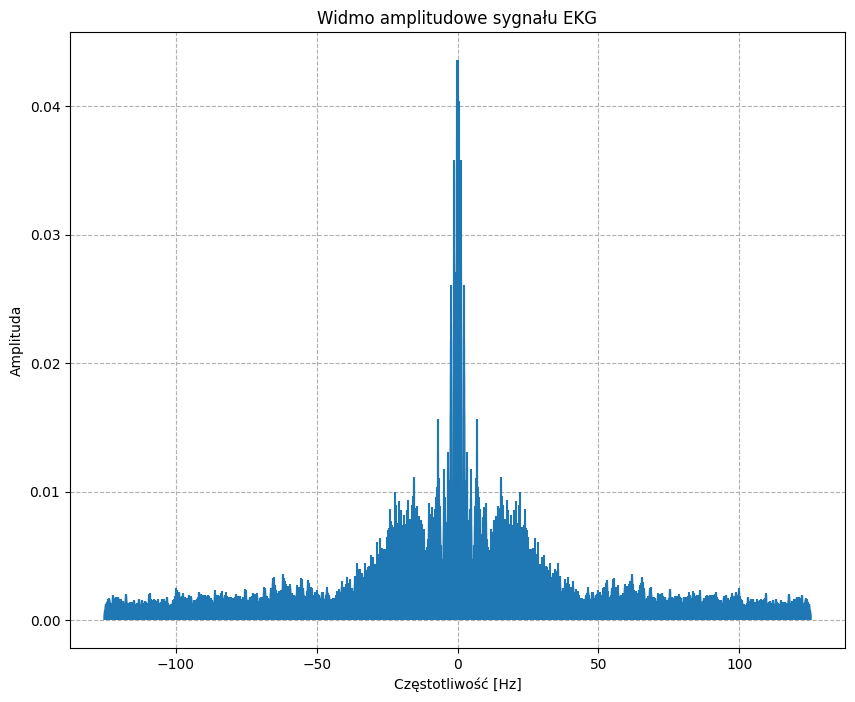

In [25]:
fft_plot(hp_filtred_signal, fs=250)

(50.5, 60.0)

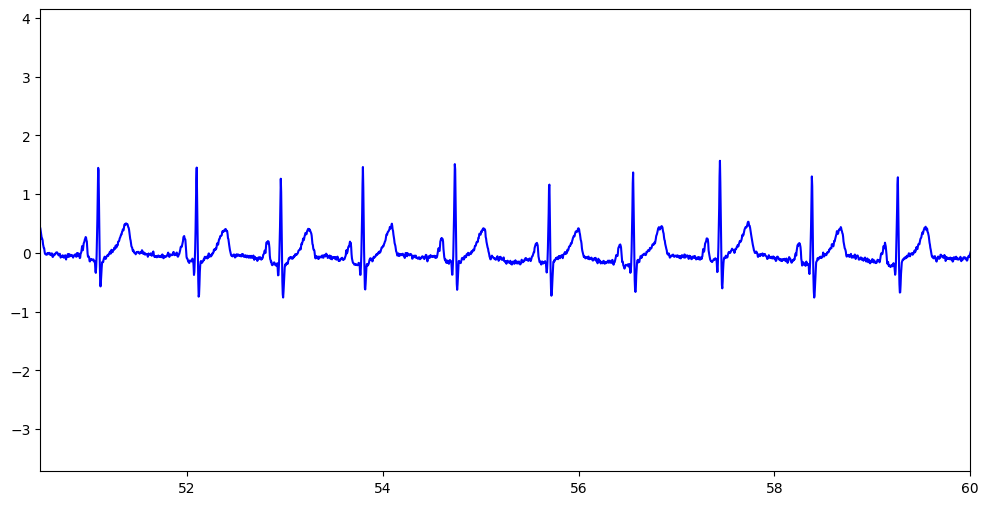

In [32]:
plt.figure(figsize=(12, 6))
plt.plot(df['Time'], hp_filtred_signal, color='blue')
plt.xlim(50.5, 60)